# Safe vs Unsafe Driving (CNN with Data Augmentation)

In [1]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Load dataset

IMG_SIZE = (96, 96)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 1554 files belonging to 2 classes.
Found 333 files belonging to 2 classes.
Found 333 files belonging to 2 classes.


In [16]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.GaussianNoise(0.03)
])

# Image rescaled to normalise by divding with 255
normalization_layer = layers.Rescaling(1./255)

# Apply augmentation only to train set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Validation & test (no augmentation)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [17]:
# Build model using Sequential() 
model = models.Sequential([
    # First CNN layer
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(96,96,3)),
    layers.MaxPooling2D(),

    # CNN layer 2
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dropout 25% of the neurons
    layers.Dropout(0.25),

    # Final fully connected layer with softmax
    layers.Dense(2, activation='softmax')
])
model.summary()

C:\Users\Aadel\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 94, 94, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │        30,978 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,066 (140.88 KB)

 Trainable params: 36,066 (140.88 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile model with categorical crossentropy loss and ADAM optimiser
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train model with 50 epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step - accuracy: 0.5226 - loss: 0.7042 - val_accuracy: 0.5946 - val_loss: 0.6837
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.5286 - loss: 0.6876 - val_accuracy: 0.6126 - val_loss: 0.6677
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.6035 - loss: 0.6710 - val_accuracy: 0.6667 - val_loss: 0.6547
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.6131 - loss: 0.6548 - val_accuracy: 0.6336 - val_loss: 0.6436
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.6453 - loss: 0.6308 - val_accuracy: 0.6366 - val_loss: 0.6171
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.6453 - loss: 0.6286 - val_accuracy: 0.6907 - val_loss: 0.5570
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.6963 - loss: 0.5848 - val_accuracy: 0.7327 - val_loss: 0.5281
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.6955 - loss: 0.5622 - val_accuracy

In [24]:
#  Model evaluation
loss, accuracy = model.evaluate(test_ds)

# Print accuracy and loss for testing
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8110 - loss: 0.3892
Test Accuracy: 82.88%
Test Loss: 0.3680


In [25]:
# Confusion matrix and classfication report
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    
cm = confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[107  46]
 [ 11 169]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       153
           1       0.79      0.94      0.86       180

    accuracy                           0.83       333
   macro avg       0.85      0.82      0.82       333
weighted avg       0.84      0.83      0.83       333



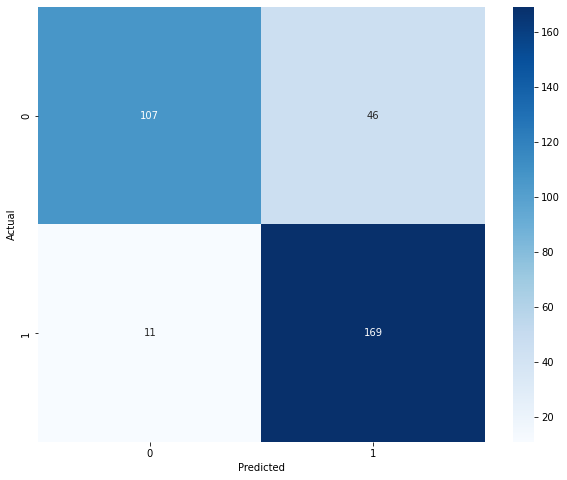

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Quantisation: Convert the model to TFLite (int8)
def representative_dataset():
    for images, _ in train_ds.take(100):
        yield [images]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEF

AULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("INT8 model saved!")

INFO:tensorflow:Assets written to: C:\Users\Aadel\AppData\Local\Temp\tmpryvb36vq\assets


INFO:tensorflow:Assets written to: C:\Users\Aadel\AppData\Local\Temp\tmpryvb36vq\assets


Saved artifact at 'C:\Users\Aadel\AppData\Local\Temp\tmpryvb36vq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_44')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1944823289632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1944823288752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1944823301568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1944823301392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1944823304032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1944823324736: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\Aadel\AppData\Roaming\Python\Python39\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model saved!
